In [22]:
from PIL import Image
import numpy as np
import torch

image = Image.open("./cat.jpg").convert("RGB")
image = image.resize((512, 512), Image.LANCZOS)
image = np.array(image).astype(np.float32) / 255.0
image = torch.from_numpy(image).permute(2, 0, 1).unsqueeze(0)
image.shape

torch.Size([1, 3, 512, 512])

In [23]:
from models.ibqgan import VQModel
from omegaconf import OmegaConf
config_path = r"D:\pyproject\awesome_tokenizer\IBQ\config\imagenet_ibqgan_16384.yaml"
ckpt_path = r"D:\pyproject\awesome_tokenizer\IBQ\checkpoint\imagenet256_16384.ckpt"
state = torch.load(ckpt_path, map_location="cpu")["state_dict"]

config = OmegaConf.load(config_path)
ddconfig = config.model.init_args.ddconfig
n_embed = config.model.init_args.n_embed
embed_dim = config.model.init_args.embed_dim
model = VQModel(ddconfig, n_embed, embed_dim)
model.load_state_dict(state, strict=False)
model.eval()


Working with z of shape (1, 256, 16, 16) = 65536 dimensions.


VQModel(
  (encoder): Encoder(
    (conv_in): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (down): ModuleList(
      (0-1): 2 x Module(
        (block): ModuleList(
          (0-3): 4 x ResnetBlock(
            (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
            (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (norm2): GroupNorm(32, 128, eps=1e-06, affine=True)
            (dropout): Dropout(p=0.0, inplace=False)
            (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          )
        )
        (attn): ModuleList()
        (downsample): Downsample(
          (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2))
        )
      )
      (2): Module(
        (block): ModuleList(
          (0): ResnetBlock(
            (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
            (conv1): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (no

In [24]:
quant, diff, info = model.encode(image)

In [25]:
reconstructed_image = model.decode(quant)

In [26]:
reconstructed_image = torch.clamp(reconstructed_image, 0.0, 1.0)
reconstructed_image = (reconstructed_image * 255.0).permute(0, 2, 3, 1).to("cpu", dtype=torch.uint8).numpy()[0]
reconstructed_image = Image.fromarray(reconstructed_image)

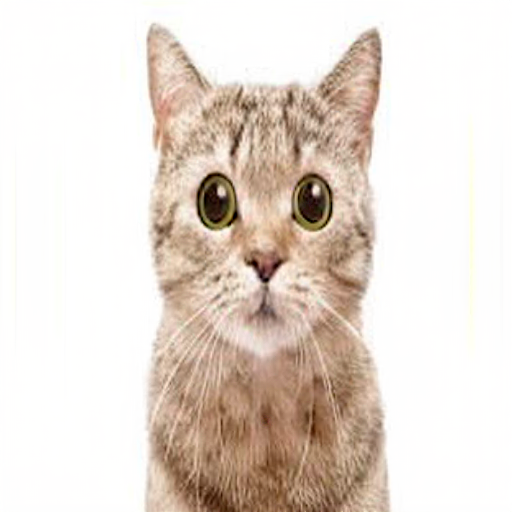

In [27]:
reconstructed_image